## 📓 Hybrid Inversion with SINDBAD-Tutorials
A notebook by Sujan Koirala, Xu Shan, Jialiang Zhou and Nuno Carvalhais

---

### 📌 Purpose

This notebook sets up and runs hybrid inversion experiments using the SINDBAD-Tutorials framework. It includes training of ML-based observation operators and the evaluation of model parameters through data assimilation.

---

## SINDBAD
[SINDBAD](http://sindbad-mdi.org/) is a model-data integration framework for terrestrial carbon-water processes [[Koirala et al., in prep.](https://essopenarchive.org/users/551954/articles/1271244)]. Is built in Julia with a view on speed and differenciability for the development of representation of processes and responses of ecosystem functioning to meteorological conditions and changes in climate. Sets on the concept of modularity to formaly test hypothesis on the representation of processes / models ($f(X,\theta)$), for given observational constraints ($Y$) and drivers ($X$) of the carbon and water dynamics in terrestrial ecosystems. Modularity is extended to the initial condition problem ($\text{x}^*_0$), cost functions ($\mathcal{L(\theta)}$) and optimization algorithms ($\mathcal{O}$). SINDBAD integrates machine learning for enhancing the representation of processes in mechanistically-inspired models, hybrid modeling [Reichstein et al., 2019], by learning ML-based parameterizations [e.g. Bao et al., 2024], paving way for process abstraction [Son et al., 2024].

---
## WROASTED: a Simple Coupled Carbon–Water Ecosystem Model
The carbon dynamics,  $\frac{dC}{dt}$, are simulated as the difference between gross assimilation and respiratory fluxes
$$
\frac{dC}{dt} = GPP - R_{ECO}
$$

where ${GPP}$, gross primary productivity, results from photosynthetic activity and $R_{ECO}$, ecosystem respiration, is the sum of autotrophic and heterotrophic respiratory fluxes, namely, $R_{A}$ and $R_{H}$. 

$R_{A}$ integrates both maintenance and growth respiration, $R_{M}$ and $R_{G}$, where  $R_{M}$  can be generically written like:

$$
R_{M} =\sum_{i=1}^{N} \tau_i \cdot C_i \cdot f_T 
$$

$i$ representing the different carbon pools ($C_i$) in vegetation - root/wood/leaf/reserves; $\tau_i$ the turnover rate of pool $i$ , and $f_T$ the temperature dependence of metabolic activity, usually a $Q_{10}$ function; while $R_G=Y_G \cdot GPP$, being $Y_G$ and constant growth efficiency parameter [see Amthor, 2001]. 

$R_H$ results from litter and soil decomposition:
$$
R_{H} =\sum_{i=1}^{N} \tau_i \cdot C_i \cdot f_T \cdot f_W
$$

$i$ representing the different heterotrophic carbon pools ($C_i$) in soils - fast and slow litter and organic carbon pools; $\tau_i$ the turnover rate of pool $i$ , $f_T$ and $f_W$ the temperature and soil moisture sensitivity of decomposition function.

Soil moisture dynamics, $\frac{dW}{dt}$:
$$
\frac{dW}{dt} = P_r - E_i - E_s - Q - D - T_r
$$

Being: $Pr$: precipitation; $E_i$: interception evaporation; $E_s$: soil evaporation; $Q$: surface runoff; $D$: drainage; $T_r$: plant transpiration.

Transpiration is tighly coupled to $GPP$, estimated as: 

$$
GPP = min(GPP_D,GPP_S)
$$

Being demand $GPP$:
$$
GPP_S = \epsilon^* \cdot f\text{APAR} \cdot \text{PAR} \cdot (f_L \cdot f_{CI} \cdot f_T \cdot f_{VPD} \cdot f_W)
$$
The product between: maximum light use efficiency, $\epsilon^*$; the fraction of photosynthetically active radiation, $\text{APAR}$, absorbed by leafs, $f\text{APAR}$; and the instantaneous effect of light intensity $f_L$, cloudiness index $f_CI$, vapor pressure deficit $f_VPD$ and soil moisture $f_W$ [see Bao et al., 2023; 2024].

And  supply $GPP$:

$$
GPP_S = PAW^{k_{Tr}} \cdot WUE
$$

Where where the daily variations in water use efficiency, $WUE$, result from changes in $VPD$ and $\quad [CO_2]_{atm}$. Upon $C$ assimilation by vegetation, and deduced $R_A$ costs, the available carbon is transported to the different vegetation pools depending on environmental conditions, as inspired by the growind season index (GSI) model [see Koirala et al., in print; Jolly et al., 2005]. 

Overall, WROASTED includes >40 parameters controlling the responses of carbon and water dynamics in terrestrial ecosystems constrainable by observations of ecosystem fluxes, eddy covariance, plant phenology from remote sensing EO data, and above ground biomass stocks, where available [see Koirala et al., in print].

---

## Simple LUE-model
Now we set a simpler model, to further test the hybrid modeling setup where solely:
$$
GPP = \epsilon^* \cdot f\text{APAR} \cdot \text{PAR} \cdot (f_L \cdot f_{CI} \cdot f_T \cdot f_{VPD} \cdot f_W)
$$

where there is not supply limitation of GPP,  $f_L=f_W=1$, $f_{VPD}$ follows PRELES [REF], $f_T$ follows CASA [Potter et al., 1993], $f_{CI}$ [Wang et al., 2015] . $f\text{APAR}$ is a constant.

---
## The challenge
To calibrate and generalize the model parameterization in space, across sites. 

In parameter inversion, the goal is to find $\theta$ such that the model predictions $f(X, \theta)$ best match observed datasets $y$. Here, the terrestrial ecosystem model, WROASTED, represented by $f(X, \theta)$, predicts a set of ecosystem carbon and water state and flux variables, $\hat{y}$, observed at locations, where: $X$: meteorological drivers (i.e., temperature, radiation, precipitation, $VPD$, etc); $\theta$: parameter vector to be estimated; $y$: observations (e.g., $GPP$, $T_r$, evapotranspiration, $R_{ECO}$, aboveground biomass AGB, $f\text{APAR}$). This can generically can be written:
$$
\theta^*=\arg\min_{\theta \in \Theta} \; \mathcal{L}(\theta)\quad\text{via}\quad\mathcal{O}
$$

Where: $\mathcal{L}(\theta)$: is the cost function quantifying the mismatch between model predictions and observations; $\Theta$: feasible parameter space (e.g., bounds or priors on $\theta$); $\mathcal{O}$: optimization operator/algorithm (e.g., gradient descent, L-BFGS, CMA-ES).

Now, for generalizing $\theta$, the challenge is to solve the following composite problem:
$$
h(X)=(f∘g)(X)=f(X,g(\dot{X}))
$$
Where, like above, $f(X,\theta)$ is a terrestrial ecosystem model, and $g(\dot{X})$ models the parameters $\theta$ of $f(X,\theta)$ depending on a ser of spatially varying features, $\dot{X}$, charaterizing conditions at locations where $y$ is observed.

As in the previous inversion exercise, for fluxes and phenology time series, the loss function $\mathcal{L}(\theta)$ is set to the normalized Nash-Sutcliffe Efficiency (NNSE)
$$
\text{NNSE}(\theta) = 1 - \frac{1}{2-NSE}
$$
$$
\text{NSE}(\theta) = 1 - \frac{\sum_{i=1}^{N} (y_i - f(X_i, \theta))^2}{\sum_{i=1}^{N} (y_i - \bar{y})^2}
$$

While for stocks, AGB, an adjusted normalized mean average error is used
$$
NMAE = \frac{\sum_{i=1}^{N} |y_i - f(X_i, \theta)|}{N \cdot (1+ \bar{y})}
$$
$$
\theta^* = \arg\min_{\theta} \; \mathcal{L}(\theta)
$$

---
## Setting up SINDBAD-Tutorials
Navigate to the [SINDBAD-Tutorials for AI4PEX repository](GitHubLink) and install. Please follow instructions. For us, [VS Code](https://code.visualstudio.com/) has been a very fluid host for [Julia](https://julialang.org/) developments.

### Get the data for these SINDBAD tutorials
The data can be found [here](https://nextcloud.bgc-jena.mpg.de/s/w2mbH59W4nF3Tcd). Suggestion, store it in a child folder of the SINDBAD-Tutorials (e.g. SINDBAD-Tutorials/data/).

### ⚙️ Setup & Dependencies

- Uses Julia packages:
  - `SindbadTutorials`, `SindbadML`, `Revise`
  - `Plots` for visualization
- Custom helper functions are imported via `tutorial_helpers.jl`
- User and OS setup is handled for Windows compatibility

---

In [2]:
import Pkg
Pkg.activate("../../")
Pkg.instantiate()

  Activating project at `~/research/RnD/SindbadTutorials.jl`
    Updating registry at `~/.julia/registries/General.toml`
   Installed libva_jll ────── v2.23.0+0
   Installed libdrm_jll ───── v2.4.125+1
   Installed MPIPreferences ─ v0.1.12
   Installed FFMPEG_jll ───── v8.0.1+1
Precompiling project...
    447.4 ms  ✓ MPIPreferences
    300.6 ms  ✓ libdrm_jll
    286.0 ms  ✓ libva_jll
    732.9 ms  ✓ MPItrampoline_jll
    741.1 ms  ✓ OpenMPI_jll
    817.9 ms  ✓ MPICH_jll
    678.6 ms  ✓ FFMPEG_jll
   1352.7 ms  ✓ HDF5_jll
   1647.8 ms  ✓ NetCDF_jll
   3030.8 ms  ✓ FFMPEG
   3257.6 ms  ✓ GR_jll
   1575.5 ms  ✓ NetCDF
   2357.8 ms  ✓ GR
   1347.2 ms  ✓ YAXArrayBase → NetCDFExt
   1293.2 ms  ✓ GR → IJuliaExt
   4373.3 ms  ✓ NCDatasets
  27032.0 ms  ✓ Plots
   2851.2 ms  ✓ Plots → IJuliaExt
   3122.7 ms  ✓ Plots → FileIOExt
  15424.3 ms  ✓ Sindbad
   8921.4 ms  ✓ Sindbad → SindbadForwardDiffExt
   8935.8 ms  ✓ Sindbad → SindbadFiniteDifferencesExt
   9053.0 ms  ✓ Sindbad → SindbadOptimisers

In [3]:
# ================================== using tools ==================================================
# some of the things that will be using... Julia tools, SINDBAD tools, local codes...
using Revise
using SindbadTutorials
using Sindbad.MachineLearning
using Sindbad.MachineLearning.Random
using SindbadTutorials.Plots
using Flux, PreallocationTools, FiniteDiff, FiniteDifferences, ForwardDiff, Optimisers

## get the sites to run experiment on
selected_site_indices = getSiteIndicesForHybrid();
do_random = 0# set to integer values larger than zero to use random selection of #do_random sites
if do_random > 0
    Random.seed!(1234)
    selected_site_indices = first(shuffle(selected_site_indices), do_random)
end

### Data and Paths
Data paths are set in `forcing.json` or `observation.json.`
Paths include:
- `path_output`: Directory for experiment outputs

Two configurations are shown:
1. **Initial Setup**: A simple experiment (commented out to avoid long run time).
2. **WROASTED Setup**: Uses a more complex model setup and runs the full pipeline including:
   - Loading experiment settings JSON
   - Preparing the hybrid inversion environment
   - Training the machine learning model


This next cell sets the experiment to run WROASTED. It takes a while. Is left here for experimenting with time, or a bigger machine...

In [ ]:
#= this one takes a larger computation time, leave it here for reference
# ================================== setting up the experiment ====================================
# experiment is all set up according to a (collection of) json file(s)
path_experiment_json    = joinpath(@__DIR__,"..","setups","WROASTED_HB","experiment_hybrid.json");
path_training_folds     = "";#joinpath(@__DIR__,"..","ellis_jena_2025","settings_WROASTED_HB","nfolds_sites_indices.jld2");

replace_info = Dict(
    "forcing.subset.site" => selected_site_indices,
    "optimization.optimization_cost_threaded" => false,
    "optimization.optimization_parameter_scaling" => nothing,
    "hybrid.ml_training.fold_path" => nothing,
);

# generate the info and other helpers
info            = getExperimentInfo(path_experiment_json; replace_info=deepcopy(replace_info));
forcing         = getForcing(info);
observations    = getObservation(info, forcing.helpers);
sites_forcing   = forcing.data[1].site;
hybrid_helpers  = prepHybrid(forcing, observations, info, info.hybrid.ml_training.method);

# ================================== train the hybrid model =======================================
trainML(hybrid_helpers, info.hybrid.ml_training.method)
=#

Continue the setup of the LUE model

In [4]:
# ================================== change setup to LUE ==========================================
# same as before, but for a faster / simpler LUE model
path_experiment_json    = joinpath(@__DIR__,"..","setups","LUE","experiment_hybrid.json");

path_training_folds     = "";#joinpath(@__DIR__,"..","ellis_jena_2025","settings_WROASTED_HB","nfolds_sites_indices.jld2");

replace_info = Dict(
    "forcing.subset.site" => selected_site_indices,
    "optimization.optimization_cost_threaded" => false,
    "optimization.optimization_parameter_scaling" => nothing,
    "hybrid.ml_training.fold_path" => nothing,
);

### generate the info and other helpers
To execute the experiment, helper structures are generated using the JSON settings and associated data paths. These include:
- `info`: the core configuration object (experiment.json, optimization.json, forcing.json) for the experiment
- `forcing`: configurations about meteorological forcing data
- `observations`: synthetic or real measurements of fluxes and states of the terrestrial biosphere model in SINDBAD
- `hybrid_helpers`: encapsulates feature preparation, training, and prediction functions...etc


In [5]:
# generate the info and other helpers
info            = getExperimentInfo(path_experiment_json; replace_info=deepcopy(replace_info));
forcing         = getForcing(info);
observations    = getObservation(info, forcing.helpers);
sites_forcing   = forcing.data[1].site;
hybrid_helpers  = prepHybrid(forcing, observations, info, info.hybrid.ml_training.method);


----------------------------------------------------------------------------------------------------

  getExperimentInfo (setupSimulationInfo.jl:38) =>  loading experiment configurations
  →→→    experiment_path: /Users/skoirala/research/RnD/SindbadTutorials.jl/tutorials/hybrid_parameter_learning/../setups/LUE/experiment_hybrid.json
  →→→    replace_info_fields:  ("optimization.optimization_parameter_scaling", "optimization.optimization_cost_threaded", "hybrid.ml_training.fold_path", "forcing.subset.site")
  readConfiguration (getConfiguration.jl:265) =>  reading configuration files
  →→→    forcing ::: /Users/skoirala/research/RnD/SindbadTutorials.jl/tutorials/hybrid_parameter_learning/../setups/LUE/forcing.json
  →→→    hybrid ::: /Users/skoirala/research/RnD/SindbadTutorials.jl/tutorials/hybrid_parameter_learning/../setups/LUE/parameter_learning_LUE.json
  →→→    model_structure ::: /Users/skoirala/research/RnD/SindbadTutorials.jl/tutorials/hybrid_parameter_learning/../setups/LUE/

### Train the model
The training of the machine learning model is performed using the `trainML` function:
```julia
trainML(hybrid_helpers, info.hybrid.ml_training.method)
```
This step uses the specified training method and data prepared in the previous steps to fit a parameter estimation model.



In [6]:
# train the model
trainML(hybrid_helpers, info.hybrid.ml_training.method)
## check the docs for output at: http://sindbad-mdi.org/pages/develop/hybrid_modeling.html and http://sindbad-mdi.org/pages/develop/sindbad_outputs.html


training... 100%|████████████████████████████████████████| Time: 0:00:48


### Posterior Diagnostics
After training, the model is used to infer site-level parameters from the input features:
```julia
params_sites = ml_model(xfeatures)
```
These inferred parameters are then rescaled to their actual physical ranges using:
```julia
scaled_params_sites = getParamsAct(params_sites, info.optimization.parameter_table)
```
This step provides a site-specific view of parameter values, which can be used for diagnostic evaluation or fed into the forward model for simulation.


In [7]:
# retrieve the inversed parameters
sites_forcing = forcing.data[1].site;
ml_model = hybrid_helpers.ml_model;
xfeatures = hybrid_helpers.features.data;
loss_functions = hybrid_helpers.loss_functions;
loss_component_functions = hybrid_helpers.loss_component_functions;

params_sites = ml_model(xfeatures)
@info "params_sites: [$(minimum(params_sites)), $(maximum(params_sites))]"

scaled_params_sites = getParamsAct(params_sites, info.optimization.parameter_table)
@info "scaled_params_sites: [$(minimum(scaled_params_sites)), $(maximum(scaled_params_sites))]"


┌ Info: params_sites: [0.49980906, 0.5001842]
└ @ Main /Users/skoirala/research/RnD/SindbadTutorials.jl/tutorials/hybrid_parameter_learning/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X24sZmlsZQ==.jl:9
┌ Info: scaled_params_sites: [0.15501124, 20.005394]
└ @ Main /Users/skoirala/research/RnD/SindbadTutorials.jl/tutorials/hybrid_parameter_learning/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X24sZmlsZQ==.jl:12


### Site-level Evaluation
To investigate performance at a specific site, one can select a site by index and extract the corresponding inferred parameters. The selected parameters are passed to the site-specific loss function to compute the loss value and its components:


In [8]:
# select a site
# idx = findfirst(x -> x == "DE-Hai", sites_forcing)
site_index = 67
site_name = sites_forcing[site_index]

loc_params = scaled_params_sites(site=site_name).data.data
loss_f_site = loss_functions(site=site_name);
loss_vector_f_site = loss_component_functions(site=site_name);
@time loss_f_site(loc_params)
loss_vector_f_site(loc_params)


  0.057495 seconds (264.00 k allocations: 14.427 MiB, 80.45% compilation time)


(0.5500778f0, Float32[0.5500778], [1])

### Site Simulation with Custom Parameters
The following function is used to run the terrestrial ecosystem model (TEM) for a selected site using either default or optimized parameters:
The function returns the simulated outputs, the loss vector, and the total scalar loss. Example usages include the following codes.
These calls allow for a direct comparison between the default and optimized model runs at the site level.

#### Arguments:
- `selected_models`: A tuple of all models selected in the given model structure.
- `loc_forcing`: A forcing NamedTuple containing the time series of environmental drivers for a single location.
- `loc_spinup_forcing`: A forcing NamedTuple for spinup, used to initialize the model to a steady state (only used if spinup is enabled).
- `loc_forcing_t`: A forcing NamedTuple for a single location and a single time step.
- `loc_output`: An output array or view for storing the model outputs for a single location.
- `loc_land`: Initial SINDBAD land NamedTuple with all fields and subfields.
- `tem_info`: A helper NamedTuple containing necessary objects for model execution and type consistencies.

The function returns the simulated outputs, the loss vector, and the total scalar loss.


In [9]:
# run the model for the site with the default parameters
function run_model_param(info, forcing, observations, site_index, loc_params)
    # info = @set info.helpers.run.land_output_type = PreAllocArrayAll();
    run_helpers = prepTEM(info.models.forward, forcing, observations, info);
    # output all variables
    # info = @set info.output.variables = run_helpers.output_vars;

    params = loc_params;
    selected_models = info.models.forward;
    parameter_scaling_type = info.optimization.run_options.parameter_scaling;
    tbl_params = info.optimization.parameter_table;
    param_to_index = getParameterIndices(selected_models, tbl_params);

    models = updateModels(params, param_to_index, parameter_scaling_type, selected_models);

    loc_forcing = run_helpers.space_forcing[site_index];
    loc_spinup_forcing = run_helpers.space_spinup_forcing[site_index];
    loc_forcing_t = run_helpers.loc_forcing_t;
    loc_output = getCacheFromOutput(run_helpers.space_output[site_index], info.hybrid.ml_gradient.method);
    gradient_lib = info.hybrid.ml_gradient.method;
    loc_output_from_cache = getOutputFromCache(loc_output, params, gradient_lib);
    land_init = deepcopy(run_helpers.loc_land);
    tem_info = run_helpers.tem_info;
    loc_obs = run_helpers.space_observation[site_index];
    loc_cost_option = prepCostOptions(loc_obs, info.optimization.cost_options);
    constraint_method = info.optimization.run_options.multi_constraint_method;
    coreTEM!(
            models,
            loc_forcing,
            loc_spinup_forcing,
            loc_forcing_t,
            loc_output_from_cache,
            land_init,
            tem_info);
    forward_output = (; Pair.(getUniqueVarNames(info.output.variables), loc_output_from_cache)...)
    loss_vector = SindbadTutorials.metricVector(loc_output_from_cache, loc_obs, loc_cost_option);
    t_loss = combineMetric(loss_vector, constraint_method);
    return forward_output, loss_vector, t_loss
end
output_default_site, _, _ = run_model_param(info, forcing, observations, 
                                            site_index, 
                                            info.optimization.parameter_table.default);



# run the model for the site with the parameters from the hybrid 
output_optimized_site, _, _ = run_model_param(info, forcing, observations, 
                                                site_index, 
                                                loc_params);


  prepTEM (prepTEM.jl:590) =>  preparing to run terrestrial ecosystem model (TEM)
     prepTEMOut (prepTEMOut.jl:367) =>  preparing output helpers for Terrestrial Ecosystem Model (TEM)
       helpPrepTEM (prepTEM.jl:401) =>  preparing spatial and tem helpers
       helpPrepTEM (prepTEM.jl:409) =>  model run for one location and time step
       helpPrepTEM (prepTEM.jl:419) =>  preallocating local, threaded, and spatial data

----------------------------------------------------------------------------------------------------

  prepTEM (prepTEM.jl:590) =>  preparing to run terrestrial ecosystem model (TEM)
     prepTEMOut (prepTEMOut.jl:367) =>  preparing output helpers for Terrestrial Ecosystem Model (TEM)
       helpPrepTEM (prepTEM.jl:401) =>  preparing spatial and tem helpers
       helpPrepTEM (prepTEM.jl:409) =>  model run for one location and time step
       helpPrepTEM (prepTEM.jl:419) =>  preallocating local, threaded, and spatial data

----------------------------------------

### Visualization and Summary Statistics
After running the model with both default and optimized parameters, this section compares their performances using time series plots and statistical metrics such as NSE (Nash–Sutcliffe Efficiency). The results are visualized for each site:
- Time series of observed vs. modeled outputs for each variable
- Overlay of default and optimized model outputs
- Evaluation metric (e.g., NSE) shown in the plot legend


plot obs::gpp


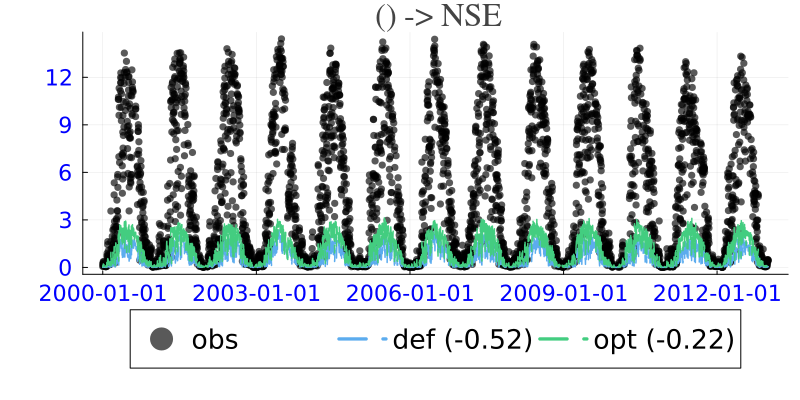

In [10]:

# do plots, compute some simple statistics e.g. NSE
def_dat = output_default_site;
opt_dat = output_optimized_site;
loc_observation = [Array(o[:, site_index]) for o in observations.data];
costOpt = prepCostOptions(loc_observation, info.optimization.cost_options);
default(titlefont=(20, "times"), legendfontsize=18, tickfont=(15, :blue), )
foreach(costOpt) do var_row
    v = var_row.variable
    println("plot obs::", v)
    v = (var_row.mod_field, var_row.mod_subfield)
    vinfo = getVariableInfo(v, info.experiment.basics.temporal_resolution)
    v = vinfo["standard_name"]
    lossMetric = var_row.cost_metric
    loss_name = nameof(typeof(lossMetric))
    if loss_name in (:NNSEInv, :NSEInv)
        lossMetric = NSE()
    end
    (obs_var, obs_σ, def_var) = getData(def_dat, loc_observation, var_row)
    (_, _, opt_var) = getData(opt_dat, loc_observation, var_row)
    obs_var_TMP = obs_var[:, 1, 1, 1]
    non_nan_index = findall(x -> !isnan(x), obs_var_TMP)
    if length(non_nan_index) < 2
        tspan = 1:length(obs_var_TMP)
    else
        tspan = first(non_nan_index):last(non_nan_index)
    end
    obs_σ = obs_σ[tspan]
    obs_var = obs_var[tspan, 1, 1, 1]
    def_var = def_var[tspan, 1, 1, 1]
    opt_var = opt_var[tspan, 1, 1, 1]

    xdata = [info.helpers.dates.range[tspan]...]
    obs_var_n, obs_σ_n, def_var_n = getDataWithoutNaN(obs_var, obs_σ, def_var)
    obs_var_n, obs_σ_n, opt_var_n = getDataWithoutNaN(obs_var, obs_σ, opt_var)
    metr_def = metric(obs_var_n, obs_σ_n, def_var_n, lossMetric)
    metr_opt = metric(obs_var_n, obs_σ_n, opt_var_n, lossMetric)
    p1 = plot(xdata, obs_var; label="obs", seriestype=:scatter, mc=:black, ms=4, lw=0, ma=0.65, left_margin=1Plots.cm)
    plot!(xdata, def_var, color=:steelblue2, lw=1.5, ls=:dash, left_margin=1Plots.cm, legend=:outerbottom, 
        legendcolumns=3, label="def ($(round(metr_def, digits=2)))", size=(800, 400), 
        title="$(vinfo["long_name"]) ($(vinfo["units"])) -> $(nameof(typeof(lossMetric)))")
    plot!(xdata, opt_var; color=:seagreen3, label="opt ($(round(metr_opt, digits=2)))", lw=1.5, ls=:dash)
    display(p1)
    savefig(joinpath(info.output.dirs.figure, "wroasted_$(site_name)_$(v).png"))
end


Additionally, for all sites, the scalar loss values (e.g., inverse NSE) are computed and stored. These are then visualized using a histogram to assess the distribution of performance across the full site ensemble:


┌ Info: 1
└ @ Main /Users/skoirala/research/RnD/SindbadTutorials.jl/tutorials/hybrid_parameter_learning/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X35sZmlsZQ==.jl:11
┌ Info: AR-SLu
└ @ Main /Users/skoirala/research/RnD/SindbadTutorials.jl/tutorials/hybrid_parameter_learning/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X35sZmlsZQ==.jl:12


  prepTEM (prepTEM.jl:590) =>  preparing to run terrestrial ecosystem model (TEM)
     prepTEMOut (prepTEMOut.jl:367) =>  preparing output helpers for Terrestrial Ecosystem Model (TEM)
       helpPrepTEM (prepTEM.jl:401) =>  preparing spatial and tem helpers
       helpPrepTEM (prepTEM.jl:409) =>  model run for one location and time step
       helpPrepTEM (prepTEM.jl:419) =>  preallocating local, threaded, and spatial data

----------------------------------------------------------------------------------------------------

  prepTEM (prepTEM.jl:590) =>  preparing to run terrestrial ecosystem model (TEM)
     prepTEMOut (prepTEMOut.jl:367) =>  preparing output helpers for Terrestrial Ecosystem Model (TEM)
       helpPrepTEM (prepTEM.jl:401) =>  preparing spatial and tem helpers
       helpPrepTEM (prepTEM.jl:409) =>  model run for one location and time step
       helpPrepTEM (prepTEM.jl:419) =>  preallocating local, threaded, and spatial data

----------------------------------------

┌ Info: running using default parameters...
└ @ Main /Users/skoirala/research/RnD/SindbadTutorials.jl/tutorials/hybrid_parameter_learning/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X35sZmlsZQ==.jl:13
┌ Info: running using optimized parameters...
└ @ Main /Users/skoirala/research/RnD/SindbadTutorials.jl/tutorials/hybrid_parameter_learning/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X35sZmlsZQ==.jl:26
┌ Info: 2
└ @ Main /Users/skoirala/research/RnD/SindbadTutorials.jl/tutorials/hybrid_parameter_learning/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X35sZmlsZQ==.jl:11
┌ Info: AR-Vir
└ @ Main /Users/skoirala/research/RnD/SindbadTutorials.jl/tutorials/hybrid_parameter_learning/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X35sZmlsZQ==.jl:12


  prepTEM (prepTEM.jl:590) =>  preparing to run terrestrial ecosystem model (TEM)
     prepTEMOut (prepTEMOut.jl:367) =>  preparing output helpers for Terrestrial Ecosystem Model (TEM)
       helpPrepTEM (prepTEM.jl:401) =>  preparing spatial and tem helpers
       helpPrepTEM (prepTEM.jl:409) =>  model run for one location and time step
       helpPrepTEM (prepTEM.jl:419) =>  preallocating local, threaded, and spatial data

----------------------------------------------------------------------------------------------------

  prepTEM (prepTEM.jl:590) =>  preparing to run terrestrial ecosystem model (TEM)
     prepTEMOut (prepTEMOut.jl:367) =>  preparing output helpers for Terrestrial Ecosystem Model (TEM)
       helpPrepTEM (prepTEM.jl:401) =>  preparing spatial and tem helpers
       helpPrepTEM (prepTEM.jl:409) =>  model run for one location and time step
       helpPrepTEM (prepTEM.jl:419) =>  preallocating local, threaded, and spatial data

----------------------------------------

┌ Info: running using default parameters...
└ @ Main /Users/skoirala/research/RnD/SindbadTutorials.jl/tutorials/hybrid_parameter_learning/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X35sZmlsZQ==.jl:13
┌ Info: running using optimized parameters...
└ @ Main /Users/skoirala/research/RnD/SindbadTutorials.jl/tutorials/hybrid_parameter_learning/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X35sZmlsZQ==.jl:26
┌ Info: 3
└ @ Main /Users/skoirala/research/RnD/SindbadTutorials.jl/tutorials/hybrid_parameter_learning/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X35sZmlsZQ==.jl:11
┌ Info: AT-Neu
└ @ Main /Users/skoirala/research/RnD/SindbadTutorials.jl/tutorials/hybrid_parameter_learning/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X35sZmlsZQ==.jl:12
┌ Info: running using default parameters...
└ @ Main /Users/skoirala/research/RnD/SindbadTutorials.jl/tutorials/hybrid_parameter_learning/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X35sZmlsZQ==.jl:13


...

┌ Info: running using optimized parameters...
└ @ Main /Users/skoirala/research/RnD/SindbadTutorials.jl/tutorials/hybrid_parameter_learning/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X35sZmlsZQ==.jl:26
┌ Info: 181
└ @ Main /Users/skoirala/research/RnD/SindbadTutorials.jl/tutorials/hybrid_parameter_learning/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X35sZmlsZQ==.jl:11
┌ Info: US-Wi9
└ @ Main /Users/skoirala/research/RnD/SindbadTutorials.jl/tutorials/hybrid_parameter_learning/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X35sZmlsZQ==.jl:12
┌ Info: running using default parameters...
└ @ Main /Users/skoirala/research/RnD/SindbadTutorials.jl/tutorials/hybrid_parameter_learning/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X35sZmlsZQ==.jl:13
┌ Info: running using optimized parameters...
└ @ Main /Users/skoirala/research/RnD/SindbadTutorials.jl/tutorials/hybrid_parameter_learning/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X35sZmlsZQ==.jl:26


  prepTEM (prepTEM.jl:590) =>  preparing to run terrestrial ecosystem model (TEM)
     prepTEMOut (prepTEMOut.jl:367) =>  preparing output helpers for Terrestrial Ecosystem Model (TEM)
       helpPrepTEM (prepTEM.jl:401) =>  preparing spatial and tem helpers
       helpPrepTEM (prepTEM.jl:409) =>  model run for one location and time step
       helpPrepTEM (prepTEM.jl:419) =>  preallocating local, threaded, and spatial data

----------------------------------------------------------------------------------------------------

  prepTEM (prepTEM.jl:590) =>  preparing to run terrestrial ecosystem model (TEM)
     prepTEMOut (prepTEMOut.jl:367) =>  preparing output helpers for Terrestrial Ecosystem Model (TEM)
       helpPrepTEM (prepTEM.jl:401) =>  preparing spatial and tem helpers
       helpPrepTEM (prepTEM.jl:409) =>  model run for one location and time step
       helpPrepTEM (prepTEM.jl:419) =>  preallocating local, threaded, and spatial data

----------------------------------------

┌ Info: 182
└ @ Main /Users/skoirala/research/RnD/SindbadTutorials.jl/tutorials/hybrid_parameter_learning/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X35sZmlsZQ==.jl:11
┌ Info: US-Wkg
└ @ Main /Users/skoirala/research/RnD/SindbadTutorials.jl/tutorials/hybrid_parameter_learning/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X35sZmlsZQ==.jl:12
┌ Info: running using default parameters...
└ @ Main /Users/skoirala/research/RnD/SindbadTutorials.jl/tutorials/hybrid_parameter_learning/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X35sZmlsZQ==.jl:13
┌ Info: running using optimized parameters...
└ @ Main /Users/skoirala/research/RnD/SindbadTutorials.jl/tutorials/hybrid_parameter_learning/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X35sZmlsZQ==.jl:26


  prepTEM (prepTEM.jl:590) =>  preparing to run terrestrial ecosystem model (TEM)
     prepTEMOut (prepTEMOut.jl:367) =>  preparing output helpers for Terrestrial Ecosystem Model (TEM)
       helpPrepTEM (prepTEM.jl:401) =>  preparing spatial and tem helpers
       helpPrepTEM (prepTEM.jl:409) =>  model run for one location and time step
       helpPrepTEM (prepTEM.jl:419) =>  preallocating local, threaded, and spatial data

----------------------------------------------------------------------------------------------------

  prepTEM (prepTEM.jl:590) =>  preparing to run terrestrial ecosystem model (TEM)
     prepTEMOut (prepTEMOut.jl:367) =>  preparing output helpers for Terrestrial Ecosystem Model (TEM)
       helpPrepTEM (prepTEM.jl:401) =>  preparing spatial and tem helpers
       helpPrepTEM (prepTEM.jl:409) =>  model run for one location and time step
       helpPrepTEM (prepTEM.jl:419) =>  preallocating local, threaded, and spatial data

----------------------------------------

┌ Info: 183
└ @ Main /Users/skoirala/research/RnD/SindbadTutorials.jl/tutorials/hybrid_parameter_learning/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X35sZmlsZQ==.jl:11
┌ Info: ZA-Kru
└ @ Main /Users/skoirala/research/RnD/SindbadTutorials.jl/tutorials/hybrid_parameter_learning/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X35sZmlsZQ==.jl:12
┌ Info: running using default parameters...
└ @ Main /Users/skoirala/research/RnD/SindbadTutorials.jl/tutorials/hybrid_parameter_learning/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X35sZmlsZQ==.jl:13
┌ Info: running using optimized parameters...
└ @ Main /Users/skoirala/research/RnD/SindbadTutorials.jl/tutorials/hybrid_parameter_learning/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X35sZmlsZQ==.jl:26
┌ Info: 184
└ @ Main /Users/skoirala/research/RnD/SindbadTutorials.jl/tutorials/hybrid_parameter_learning/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X35sZmlsZQ==.jl:11
┌ Info: ZM-Mon
└ @ Main /Users/skoirala/research/RnD/Sin

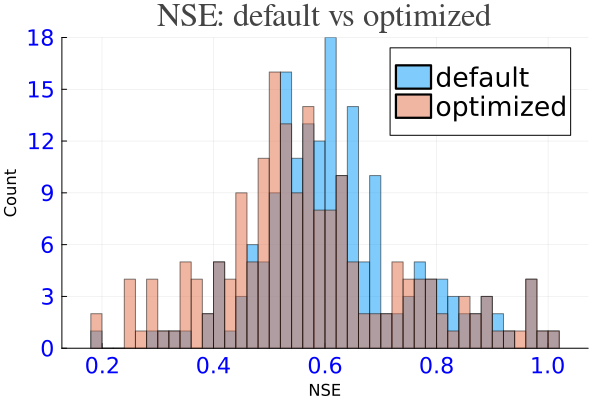

  prepTEM (prepTEM.jl:590) =>  preparing to run terrestrial ecosystem model (TEM)
     prepTEMOut (prepTEMOut.jl:367) =>  preparing output helpers for Terrestrial Ecosystem Model (TEM)
       helpPrepTEM (prepTEM.jl:401) =>  preparing spatial and tem helpers
       helpPrepTEM (prepTEM.jl:409) =>  model run for one location and time step
       helpPrepTEM (prepTEM.jl:419) =>  preallocating local, threaded, and spatial data

----------------------------------------------------------------------------------------------------



"/Users/skoirala/research/RnD/SindbadTutorials.jl/output_FLUXNET_LUE/figure/loss_histogram_scalar.png"

In [11]:

# preallocate
n_sites = length(sites_forcing);
t_loss_def = Vector{Float32}(undef, n_sites);
t_loss_opt = Vector{Float32}(undef, n_sites);

# for (i, site_index) in enumerate(1:n_sites)
# i = 1
# for site_index in hybrid_helpers.indices.testing
for (i, site_index) in enumerate(1:n_sites)
    @info site_index
    @info sites_forcing[site_index]
    @info "running using default parameters..."
    # # the following way could be faster to run...
    # loss_f_site = loss_functions(site=site_name);
    # loss_vector_f_site = loss_component_functions(site=site_name);
    # loss_f_site(loc_params)
    # loss_vector_f_site(loc_params)

    # run default
    _, lv_def, tl_def = run_model_param(
       info, forcing, observations, site_index,
       info.optimization.parameter_table.default
    )
    # run optimized
    @info "running using optimized parameters..."
    _, lv_opt, tl_opt = run_model_param(
       info, forcing, observations, site_index,
       scaled_params_sites(site=sites_forcing[site_index]).data.data
    )
    # collect
    t_loss_def[i]     = tl_def
    t_loss_opt[i]     = tl_opt
    # i += 1
end

# now plot histogram of scalar losses
h1 = histogram(
  t_loss_def,
  bins = 50,
  alpha = 0.5,
  label = "default",
  xlabel = "NSE",
  ylabel = "Count",
  title = "NSE: default vs optimized"
)
histogram!(
  t_loss_opt,
  bins = 50,
  alpha = 0.5,
  label = "optimized"
)
display(h1)
savefig(joinpath(info.output.dirs.figure, "loss_histogram_scalar.png"))


In [ ]:
# now plot histogram of scalar losses
h2 = histogram(
  t_loss_def .- t_loss_opt,
  bins = 50,
  alpha = 0.5,
  label = "default",
  xlabel = "NSE",
  ylabel = "Count",
  title = "NSE: default - optimized"
)
# histogram!(
#   t_loss_opt,
#   bins = 50,
#   alpha = 0.5,
#   label = "optimized"
# )
display(h2)
savefig(joinpath(info.output.dirs.figure, "loss_diff_histogram_scalar.png"))

In [ ]:
hybrid_helpers